In [1]:
import pathlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
eval_plot_dir = pathlib.Path(".") / "eval_plots"
if not eval_plot_dir.exists():
    raise FileNotFoundError(f"Expected evaluation plot directory {eval_plot_dir} does not exist. Please run the notebook cells in order to generate model fitting results and save to this directory before attempting to visualize.")

enriched_df = pd.read_csv(eval_plot_dir / "model_fit_summary.csv")
if enriched_df.empty:
    raise ValueError(f"Loaded model fit summary from {eval_plot_dir / 'model_fit_summary.csv'} is empty. Please check that the model fitting notebook ran successfully and saved results to this file before attempting to visualize.")

In [3]:
# Path to directory with feature selected profiles
path_to_feature_selected_data = pathlib.Path().home() / "mnt" / "bandicoot" /\
    "CFReT_screening_data" / "screen_profiles"
if not path_to_feature_selected_data.exists() and\
    not path_to_feature_selected_data.is_dir():
    raise FileNotFoundError(
        f"Directory {path_to_feature_selected_data} does not exist or is not a directory."
    )

# Find all batch folders
batch_folders = list(path_to_feature_selected_data.glob("batch*"))
batch_folders = [folder for folder in batch_folders if folder.is_dir()]
if not batch_folders:
    raise FileNotFoundError(
        f"No batch folders found in {path_to_feature_selected_data}."
    )

batch2plate = []
for batch_folder in batch_folders:
    feature_selected_files = list(
        batch_folder.rglob("**/single_cell_profiles/*_feature_selected.parquet")
    )
    if not feature_selected_files:
        continue

    for file in feature_selected_files:
        plate_repr = "_".join(pathlib.Path(file).stem.split("_")[:2])

        batch2plate.append({
            "batch": batch_folder.name,
            "plate": plate_repr,
        })

batch2plate_df = pd.DataFrame(batch2plate)
display(batch2plate_df)

,batch,plate
0,batch_1,CARD-CelIns-CX7_251210180001
1,batch_1,CARD-CelIns-CX7_251203170001
2,batch_1,CARD-CelIns-CX7_251205100001
3,batch_1,CARD-CelIns-CX7_251208160001
4,batch_1,CARD-CelIns-CX7_251212180001
5,batch_1,CARD-CelIns-CX7_251211180001
6,batch_1,CARD-CelIns-CX7_251212100001
7,batch_1,CARD-CelIns-CX7_251213150001
8,batch_1,CARD-CelIns-CX7_251201190001
9,batch_1,CARD-CelIns-CX7_251201110001


In [4]:
enriched_df_batch = pd.merge(
    enriched_df,
    batch2plate_df,
    on="plate",
    how="inner"
)
enriched_df_batch['batch'] = enriched_df_batch['batch'].apply(lambda x: int(x.replace("batch_", "")))
display(enriched_df_batch)

,plate,fold,shuffled,n_train,n_test,n_input_features,n_selected_features,average_precision,roc_auc,train_n,test_n,train_failing,train_healthy,test_failing,test_healthy,batch
0,CARD-CelIns-CX7_251220120001,0,False,1275,487,933,31,0.975931,0.975073,1275,487,"['E02', 'E08', 'E11']","['B02', 'B08', 'B11']",['E05'],['B05'],2
1,CARD-CelIns-CX7_251220120001,0,True,1275,487,933,21,0.456203,0.399936,1275,487,"['E02', 'E08', 'E11']","['B02', 'B08', 'B11']",['E05'],['B05'],2
2,CARD-CelIns-CX7_251220120001,1,False,1351,411,933,33,0.999736,0.999716,1311,451,"['E02', 'E05', 'E08']","['B02', 'B05', 'B08']",['E11'],['B11'],2
3,CARD-CelIns-CX7_251220120001,1,True,1351,411,933,33,0.570686,0.529037,1311,451,"['E02', 'E05', 'E08']","['B02', 'B05', 'B08']",['E11'],['B11'],2
4,CARD-CelIns-CX7_251220120001,2,False,1366,396,933,34,0.977535,0.980693,1366,396,"['E05', 'E08', 'E11']","['B02', 'B05', 'B11']",['E02'],['B08'],2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,CARD-CelIns-CX7_260111110001,1,True,814,243,921,16,0.402674,0.515574,814,243,"['E02', 'E05', 'E08']","['B02', 'B05', 'B08']",['E11'],['B11'],3
348,CARD-CelIns-CX7_260111110001,2,False,745,312,921,14,0.958886,0.979110,745,312,"['E02', 'E08', 'E11']","['B02', 'B08', 'B11']",['E05'],['B05'],3
349,CARD-CelIns-CX7_260111110001,2,True,745,312,921,14,0.429569,0.450068,745,312,"['E02', 'E08', 'E11']","['B02', 'B08', 'B11']",['E05'],['B05'],3
350,CARD-CelIns-CX7_260111110001,3,False,812,245,921,16,0.973387,0.981109,812,245,"['E02', 'E05', 'E11']","['B02', 'B05', 'B11']",['E08'],['B08'],3


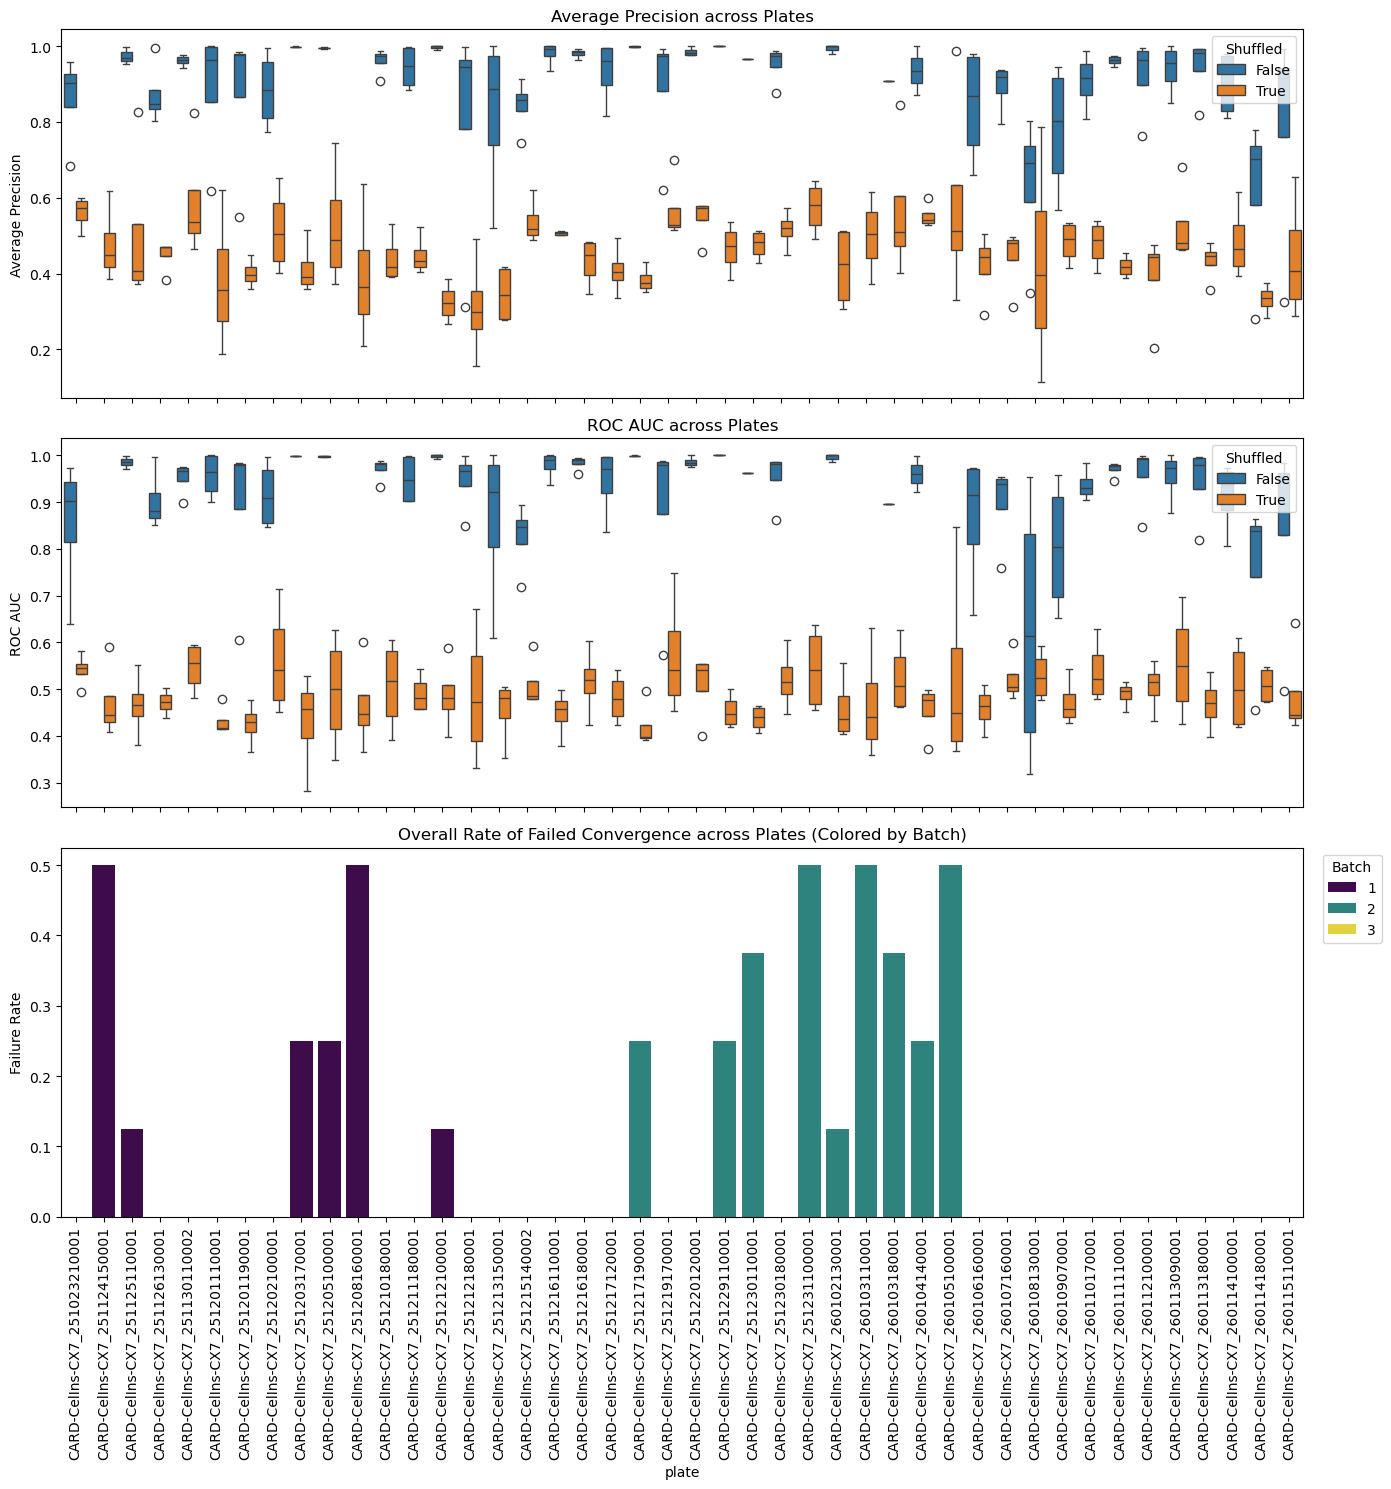

In [5]:
# Use enriched_df_batch to have the batch information available for everything
enriched_df_batch['convergence_failed'] = enriched_df_batch['average_precision'].isna() | enriched_df_batch['roc_auc'].isna()

# Sort the data by batch and plate to keep plates from the same batch together on the x-axis
enriched_df_batch = enriched_df_batch.sort_values(by=['batch', 'plate'])

# Calculate overall convergence failure rate per plate (averaging across both shuffled and original)
failure_rates = enriched_df_batch.groupby(['batch', 'plate'])['convergence_failed'].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# 1. Boxplot for Average Precision
sns.boxplot(data=enriched_df_batch, x='plate', y='average_precision', hue='shuffled', ax=axes[0])
axes[0].set_title('Average Precision across Plates')
axes[0].set_ylabel('Average Precision')
axes[0].legend(title='Shuffled', loc='upper right')

# 2. Boxplot for ROC AUC
sns.boxplot(data=enriched_df_batch, x='plate', y='roc_auc', hue='shuffled', ax=axes[1])
axes[1].set_title('ROC AUC across Plates')
axes[1].set_ylabel('ROC AUC')
axes[1].legend(title='Shuffled', loc='upper right')

# 3. Barplot for failed convergence rate (Colored by Batch)
# Dodge=False ensures bars span correctly across plates since each plate only belongs to one batch
sns.barplot(
    data=failure_rates, 
    x='plate', 
    y='convergence_failed', 
    hue='batch', 
    dodge=False, 
    palette='viridis', 
    ax=axes[2]
)
axes[2].set_title('Overall Rate of Failed Convergence across Plates (Colored by Batch)')
axes[2].set_ylabel('Failure Rate')
axes[2].tick_params(axis='x', rotation=90)
axes[2].legend(title='Batch', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

fig.savefig(
    pathlib.Path("eval_plots") / "plate_metric_convergence_summary.png",
    dpi=300,
    bbox_inches="tight"
)